In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install torch torchvision tqdm scikit-learn


Mounted at /content/drive


In [ ]:
import os
import gc
import json
import numpy as np
import pandas as pd
from tqdm import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import models, transforms
from sklearn.metrics import classification_report


In [ ]:
DATA_DIR = "/content/drive/MyDrive/IRP_2/data/fer2013.csv"
MODEL_ROOT = "/content/drive/MyDrive/IRP_2/models"

BATCH_SIZE = 128
EVAL_BATCH_SIZE = 16
EPOCHS = 120
PATIENCE = 10
NUM_CLASSES = 7

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)


Using device: cuda


In [ ]:
class FERDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        pixels = np.array(self.df.iloc[idx]['pixels'].split(), dtype=np.uint8)
        img = pixels.reshape(48, 48)
        img = Image.fromarray(img).convert("RGB")
        label = int(self.df.iloc[idx]['emotion'])

        if self.transform:
            img = self.transform(img)

        return img, label


In [ ]:
train_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2,0.2,0.1,0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485]*3, [0.229]*3)
])

eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.TenCrop(224),
    transforms.Lambda(lambda crops: torch.stack([
        transforms.Normalize([0.485]*3, [0.229]*3)(
            transforms.ToTensor()(c)) for c in crops
    ]))
])


In [ ]:
df = pd.read_csv(DATA_DIR)

train_df   = df[df["Usage"] == "Training"]
public_df  = df[df["Usage"] == "PublicTest"]
private_df = df[df["Usage"] == "PrivateTest"]

train_ds   = FERDataset(train_df, train_tf)
public_ds  = FERDataset(public_df, eval_tf)
private_ds = FERDataset(private_df, eval_tf)

train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
public_loader = DataLoader(public_ds, EVAL_BATCH_SIZE, shuffle=False, num_workers=4)
private_loader = DataLoader(private_ds, EVAL_BATCH_SIZE, shuffle=False, num_workers=4)

print("Train:", len(train_ds), "Public:", len(public_ds), "Private:", len(private_ds))


Train: 28709 Public: 3589 Private: 3589


In [ ]:
def get_model(name):
    if name == "VGG19":
        model = models.vgg19(weights=models.VGG19_Weights.DEFAULT)
        model.classifier[6] = nn.Linear(4096, NUM_CLASSES)

    elif name == "ResNet18":
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

    return model.to(DEVICE)


In [ ]:
def train(model, model_name):
    save_dir = f"{MODEL_ROOT}/FER_{model_name}"
    os.makedirs(save_dir, exist_ok=True)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5)

    best_acc = 0
    patience_count = 0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        correct = total = loss_sum = 0

        for x, y in tqdm(train_loader, leave=False):
            x, y = x.to(DEVICE), y.to(DEVICE)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            loss_sum += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)

        acc = correct / total
        scheduler.step(1 - acc)

        print(f"{model_name} | Epoch {epoch} | Loss: {loss_sum/total:.4f} | Acc: {acc:.4f}")

        if acc > best_acc:
            best_acc = acc
            patience_count = 0
            torch.save(model.state_dict(), f"{save_dir}/best.pth")
            print("Best model saved")
        else:
            patience_count += 1
            if patience_count >= PATIENCE:
                print("Early stopping")
                break


In [ ]:
def evaluate(model, loader, name):
    model.eval()
    preds, labels = [], []

    with torch.no_grad():
        for x, y in tqdm(loader, desc=name):
            bs, ncrops, c, h, w = x.size()
            x = x.view(-1, c, h, w).to(DEVICE)

            out = model(x)
            out = out.view(bs, ncrops, -1).mean(1)

            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(y.numpy())

    print("\n", name)
    print(classification_report(labels, preds, digits=4))


In [ ]:
torch.cuda.empty_cache()
gc.collect()

0

In [ ]:
vgg = get_model("VGG19")
train(vgg, "VGG19")


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:02<00:00, 236MB/s]


VGG19 | Epoch 1 | Loss: 1.8449 | Acc: 0.2477
Best model saved


VGG19 | Epoch 2 | Loss: 1.8334 | Acc: 0.2515
Best model saved


VGG19 | Epoch 3 | Loss: 1.7698 | Acc: 0.2938
Best model saved


...

VGG19 | Epoch 116 | Loss: 1.0291 | Acc: 0.7226
Best model saved


VGG19 | Epoch 117 | Loss: 1.0031 | Acc: 0.7345
Best model saved


VGG19 | Epoch 118 | Loss: 0.9955 | Acc: 0.7424
Best model saved


VGG19 | Epoch 119 | Loss: 0.9884 | Acc: 0.7442
Best model saved


VGG19 | Epoch 120 | Loss: 0.9764 | Acc: 0.7473
Best model saved


In [ ]:
torch.cuda.empty_cache()
gc.collect()

evaluate(vgg, public_loader, "VGG19 PublicTest")
evaluate(vgg, private_loader, "VGG19 PrivateTest")


VGG19 PublicTest: 100%|██████████| 225/225 [01:49<00:00,  2.05it/s]



 VGG19 PublicTest
              precision    recall  f1-score   support

           0     0.6166    0.6510    0.6333       467
           1     0.8500    0.6071    0.7083        56
           2     0.5892    0.5060    0.5445       496
           3     0.8812    0.8782    0.8797       895
           4     0.5908    0.5881    0.5894       653
           5     0.8169    0.8386    0.8276       415
           6     0.6314    0.6886    0.6588       607

    accuracy                         0.7035      3589
   macro avg     0.7109    0.6797    0.6917      3589
weighted avg     0.7034    0.7035    0.7024      3589



VGG19 PrivateTest: 100%|██████████| 225/225 [01:49<00:00,  2.06it/s]


 VGG19 PrivateTest
              precision    recall  f1-score   support

           0     0.6524    0.6538    0.6531       491
           1     0.9500    0.6909    0.8000        55
           2     0.6051    0.5398    0.5706       528
           3     0.8966    0.8976    0.8971       879
           4     0.5703    0.6010    0.5852       594
           5     0.8164    0.8125    0.8145       416
           6     0.6787    0.7220    0.6997       626

    accuracy                         0.7189      3589
   macro avg     0.7385    0.7025    0.7172      3589
weighted avg     0.7198    0.7189    0.7186      3589



In [ ]:
torch.cuda.empty_cache()
gc.collect()

In [ ]:
resnet = get_model("ResNet18")
train(resnet, "ResNet18")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 193MB/s]


ResNet18 | Epoch 1 | Loss: 1.5621 | Acc: 0.4359
Best model saved


ResNet18 | Epoch 2 | Loss: 1.4237 | Acc: 0.5112
Best model saved


ResNet18 | Epoch 3 | Loss: 1.3701 | Acc: 0.5368
Best model saved


...

ResNet18 | Epoch 116 | Loss: 0.7646 | Acc: 0.8550


ResNet18 | Epoch 117 | Loss: 0.7580 | Acc: 0.8588
Best model saved


ResNet18 | Epoch 118 | Loss: 0.7538 | Acc: 0.8626
Best model saved


ResNet18 | Epoch 119 | Loss: 0.7581 | Acc: 0.8581


ResNet18 | Epoch 120 | Loss: 0.7565 | Acc: 0.8619


In [ ]:
torch.cuda.empty_cache()
gc.collect()

evaluate(resnet, public_loader, "ResNet18 PublicTest")
evaluate(resnet, private_loader, "ResNet18 PrivateTest")


ResNet18 PublicTest: 100%|██████████| 225/225 [00:24<00:00,  9.18it/s]



 ResNet18 PublicTest
              precision    recall  f1-score   support

           0     0.6236    0.6103    0.6169       467
           1     0.9429    0.5893    0.7253        56
           2     0.5900    0.5484    0.5684       496
           3     0.8717    0.8883    0.8799       895
           4     0.5860    0.6263    0.6055       653
           5     0.8634    0.7614    0.8092       415
           6     0.6136    0.6672    0.6393       607

    accuracy                         0.7008      3589
   macro avg     0.7273    0.6702    0.6921      3589
weighted avg     0.7050    0.7008    0.7014      3589



ResNet18 PrivateTest: 100%|██████████| 225/225 [00:24<00:00,  9.12it/s]



 ResNet18 PrivateTest
              precision    recall  f1-score   support

           0     0.6369    0.6110    0.6237       491
           1     0.8837    0.6909    0.7755        55
           2     0.6100    0.5985    0.6042       528
           3     0.8841    0.9022    0.8930       879
           4     0.5672    0.6465    0.6042       594
           5     0.8889    0.7500    0.8136       416
           6     0.6804    0.6869    0.6836       626

    accuracy                         0.7169      3589
   macro avg     0.7359    0.6980    0.7140      3589
weighted avg     0.7225    0.7169    0.7184      3589



In [ ]:
def compute_accuracy(model, loader, use_tencrop=False):
    model.eval()
    correct = total = 0

    with torch.no_grad():
        for x, y in loader:
            y = y.to(DEVICE)

            if use_tencrop:
                bs, ncrops, c, h, w = x.size()
                x = x.view(-1, c, h, w).to(DEVICE)
                out = model(x)
                out = out.view(bs, ncrops, -1).mean(1)
            else:
                x = x.to(DEVICE)
                out = model(x)

            preds = out.argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total


In [ ]:
def compute_accuracy(model, loader, use_tencrop=False):
    model.eval()
    correct = total = 0

    with torch.no_grad():
        for x, y in loader:
            y = y.to(DEVICE)

            if use_tencrop:
                bs, ncrops, c, h, w = x.size()
                x = x.view(-1, c, h, w).to(DEVICE)
                out = model(x)
                out = out.view(bs, ncrops, -1).mean(1)
            else:
                x = x.to(DEVICE)
                out = model(x)

            preds = out.argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total


In [ ]:
results = {}

vgg_best = get_model("VGG19")
vgg_best.load_state_dict(torch.load(f"{MODEL_ROOT}/FER_VGG19/best.pth"))

resnet_best = get_model("ResNet18")
resnet_best.load_state_dict(torch.load(f"{MODEL_ROOT}/FER_ResNet18/best.pth"))

results["VGG19"] = {
    "train": compute_accuracy(vgg_best, train_loader, use_tencrop=False),
    "public": compute_accuracy(vgg_best, public_loader, use_tencrop=True),
    "private": compute_accuracy(vgg_best, private_loader, use_tencrop=True)
}

results["ResNet18"] = {
    "train": compute_accuracy(resnet_best, train_loader, use_tencrop=False),
    "public": compute_accuracy(resnet_best, public_loader, use_tencrop=True),
    "private": compute_accuracy(resnet_best, private_loader, use_tencrop=True)
}

results

{'VGG19': {'train': 0.755059389041764,
  'public': 0.7035385901365283,
  'private': 0.7188631930899972},
 'ResNet18': {'train': 0.8638754397575673,
  'public': 0.7079966564502647,
  'private': 0.7314015045973808}}

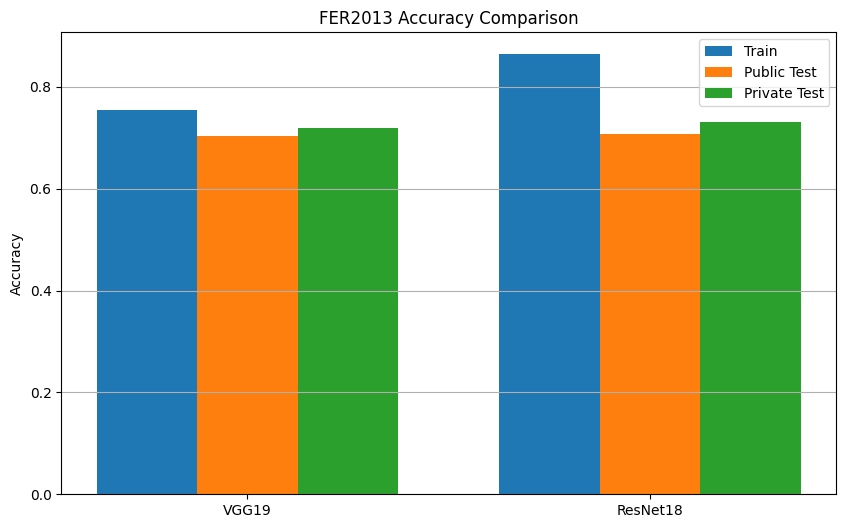

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = list(results.keys())
train_acc = [results[m]["train"] for m in models]
public_acc = [results[m]["public"] for m in models]
private_acc = [results[m]["private"] for m in models]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10,6))
plt.bar(x - width, train_acc, width, label="Train")
plt.bar(x, public_acc, width, label="Public Test")
plt.bar(x + width, private_acc, width, label="Private Test")

plt.xticks(x, models)
plt.ylabel("Accuracy")
plt.title("FER2013 Accuracy Comparison")
plt.legend()
plt.grid(axis="y")

plt.show()


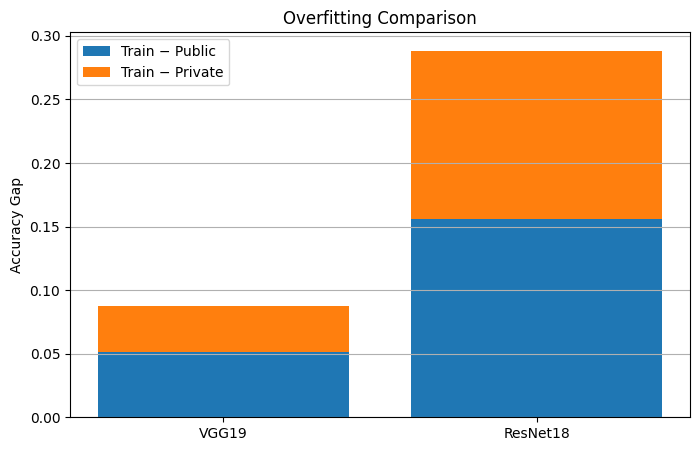

In [ ]:
overfit_gap_public = [
    results[m]["train"] - results[m]["public"] for m in models
]

overfit_gap_private = [
    results[m]["train"] - results[m]["private"] for m in models
]

plt.figure(figsize=(8,5))
plt.bar(models, overfit_gap_public, label="Train − Public")
plt.bar(models, overfit_gap_private, bottom=overfit_gap_public, label="Train − Private")

plt.ylabel("Accuracy Gap")
plt.title("Overfitting Comparison")
plt.legend()
plt.grid(axis="y")

plt.show()


In [ ]:
for m in models:
    print(f"\n{m}")
    print(f" Train Accuracy   : {results[m]['train']:.4f}")
    print(f" Public Accuracy  : {results[m]['public']:.4f}")
    print(f" Private Accuracy : {results[m]['private']:.4f}")
    print(f" Overfit Gap (Public)  : {(results[m]['train'] - results[m]['public']):.4f}")
    print(f" Overfit Gap (Private) : {(results[m]['train'] - results[m]['private']):.4f}")



VGG19
 Train Accuracy   : 0.7551
 Public Accuracy  : 0.7035
 Private Accuracy : 0.7189
 Overfit Gap (Public)  : 0.0515
 Overfit Gap (Private) : 0.0362

ResNet18
 Train Accuracy   : 0.8639
 Public Accuracy  : 0.7080
 Private Accuracy : 0.7314
 Overfit Gap (Public)  : 0.1559
 Overfit Gap (Private) : 0.1325
